# Perceptron Learning Algorithm
## Logic Gates Implementation with Decision Boundary Visualization

---

### Overview

This notebook implements the **Perceptron Learning Algorithm** for:

- **Part 1:** OR, NOT, and AND gates (linearly separable → converges)
- **Part 2:** XOR gate (not linearly separable → does not converge)

### Perceptron Update Rule

$$w_i \leftarrow w_i + \eta (y - \hat{y})x_i$$

$$b \leftarrow b + \eta (y - \hat{y})$$

#### Rule Breakdown
* **$w_i$**: The weight value for input $x_i$.
* **$b$**: The bias value.
* **$\eta$**: The learning rate step size.
* **$y$**: The true target label.
* **$\hat{y}$**: The predicted output value.

where

- **η** = learning rate
- **y** = true label
- **ŷ** = predicted label

The activation function is

$$\hat{y}=
\begin{cases}
1,&\text{if } \mathbf{w}\cdot\mathbf{x}+b\ge0\\
0,&\text{otherwise}
\end{cases}$$

---



Epoch 1/10 | Misclassifications: 2 | Weights: [0.  0.1] | Bias: 0.0


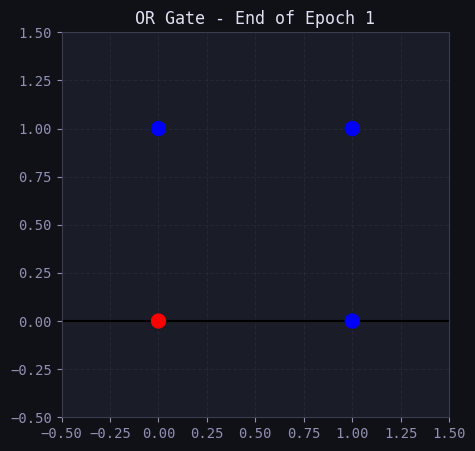

Epoch 2/10 | Misclassifications: 2 | Weights: [0.1 0.1] | Bias: 0.0


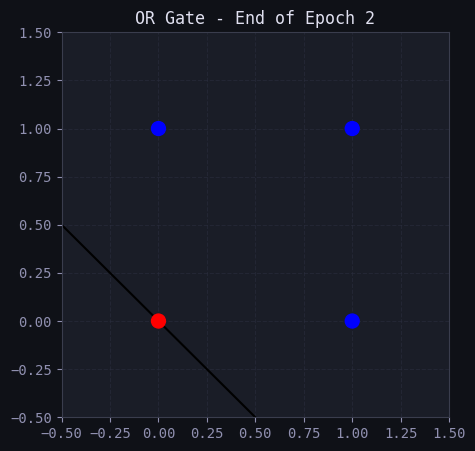

Epoch 3/10 | Misclassifications: 1 | Weights: [0.1 0.1] | Bias: -0.1


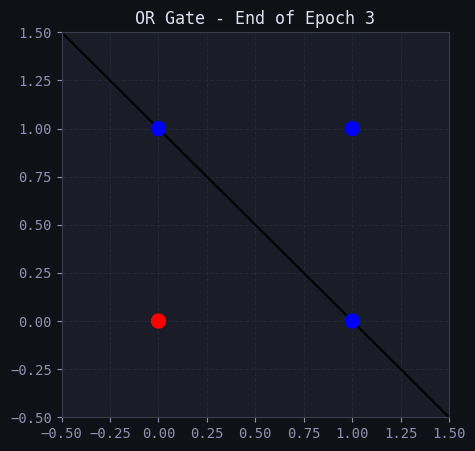

Epoch 4/10 | Misclassifications: 0 | Weights: [0.1 0.1] | Bias: -0.1


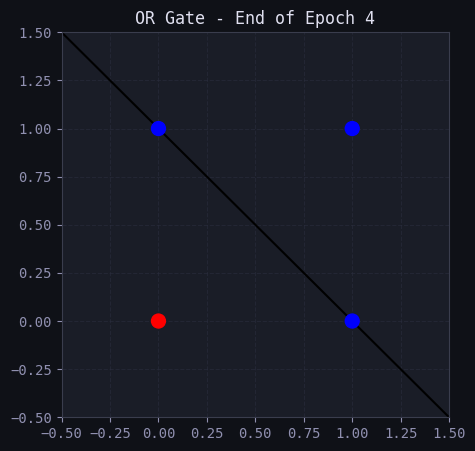


Model converged early at Epoch 4!

OPTIMAL PARAMETERS FOUND
Final Weights : w1 = 0.10, w2 = 0.10
Final Bias    : b  = -0.10
Total Updates : 5


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# OR Gate Data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])

lr = 0.1
epochs = 10

w = np.zeros(2)
b = 0

def plot_boundary(X, y, w, b, title):
    plt.figure(figsize=(5, 5))

    # Red for class 0, Blue for class 1
    colors = ['red' if i == 0 else 'blue' for i in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, s=100, zorder=3)

    # Plot decision boundary w0*x + w1*y + b = 0 -> y = -(w0*x + b)/w1
    if abs(w[1]) > 1e-6:
        x_pts = np.linspace(-0.5, 1.5, 100)
        y_pts = -(w[0] * x_pts + b) / w[1]
        plt.plot(x_pts, y_pts, 'k-', label='Decision Boundary')
    elif abs(w[0]) > 1e-6:
        # Vertical line fallback if w1 is 0 but w0 is non-zero
        x_val = -b / w[0]
        plt.axvline(x=x_val, color='k', label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.title(title)
    plt.show()

# Training Loop
total_updates = 0

for epoch in range(epochs):
    epoch_errors = 0
    
    for xi, target in zip(X, y):
        net = np.dot(xi, w) + b
        pred = 1 if net >= 0 else 0
        error = target - pred

        if error != 0:
            w += lr * error * xi
            b += lr * error
            total_updates += 1
            epoch_errors += 1

    # Print status and plot boundary once per epoch
    print(f"Epoch {epoch + 1}/{epochs} | Misclassifications: {epoch_errors} | Weights: {np.round(w, 2)} | Bias: {round(b, 2)}")
    plot_boundary(X, y, w, b, f"OR Gate - End of Epoch {epoch + 1}")

    # Early stopping if converged (0 errors across the full dataset)
    if epoch_errors == 0:
        print(f"\nModel converged early at Epoch {epoch + 1}!")
        break

# Final Output
print("\n" + "="*30)
print("OPTIMAL PARAMETERS FOUND")
print("="*30)
print(f"Final Weights : w1 = {w[0]:.2f}, w2 = {w[1]:.2f}")
print(f"Final Bias    : b  = {b:.2f}")
print(f"Total Updates : {total_updates}")

Epoch 1/10 | Errors: 1 | Weights: [0.1 0.1] | Bias: 0.1


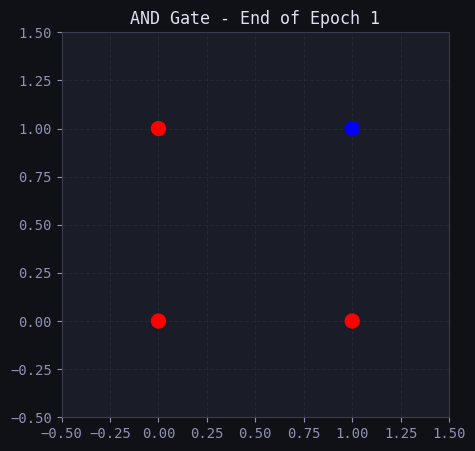

Epoch 2/10 | Errors: 3 | Weights: [0.2 0.1] | Bias: 0.0


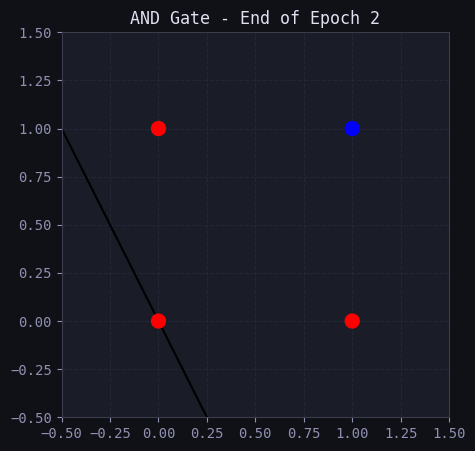

Epoch 3/10 | Errors: 3 | Weights: [0.2 0.1] | Bias: -0.1


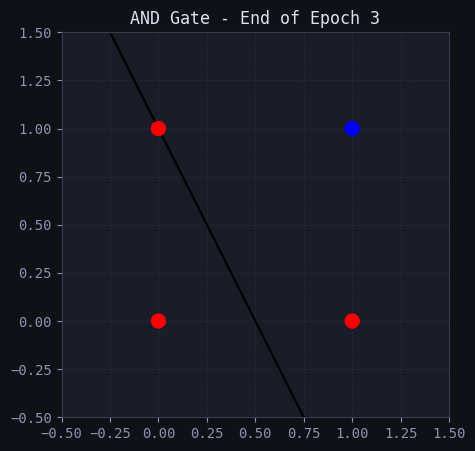

Epoch 4/10 | Errors: 2 | Weights: [0.2 0.2] | Bias: -0.1


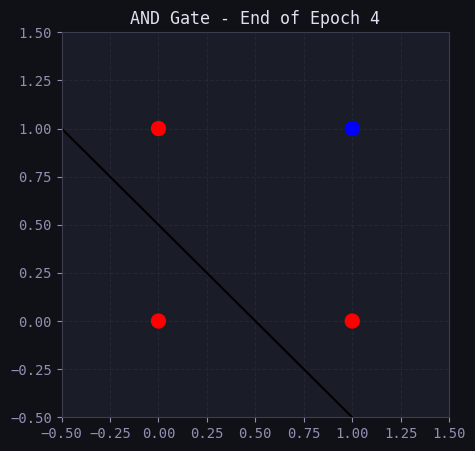

Epoch 5/10 | Errors: 1 | Weights: [0.2 0.1] | Bias: -0.2


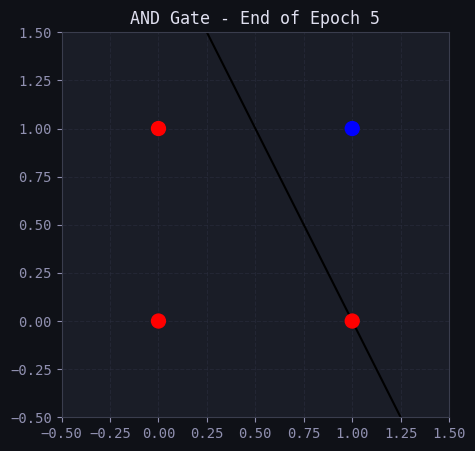

Epoch 6/10 | Errors: 0 | Weights: [0.2 0.1] | Bias: -0.2


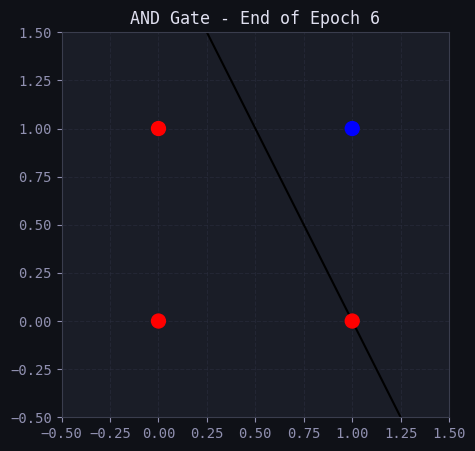


Optimal split achieved! Converged at Epoch 6.

OPTIMAL PARAMETERS FOUND
Final Weights : w1 = 0.200, w2 = 0.100
Final Bias    : b  = -0.200


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# AND Gate Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# Smaller learning rate guarantees fine updates so the line stays off points
lr = 0.1  
epochs = 10

w = np.zeros(2)
b = 0  # Slight negative offset prevents net == 0 on grid coordinates

def plot_boundary(X, y, w, b, title):
    plt.figure(figsize=(5, 5))

    colors = ['red' if i == 0 else 'blue' for i in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, s=100, zorder=3)

    if abs(w[1]) > 1e-6:
        x_pts = np.linspace(-0.5, 1.5, 100)
        y_pts = -(w[0] * x_pts + b) / w[1]
        plt.plot(x_pts, y_pts, 'k-', label='Decision Boundary')
    elif abs(w[0]) > 1e-6:
        x_val = -b / w[0]
        plt.axvline(x=x_val, color='k', label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.title(title)
    plt.show()

# Training Loop
total_updates = 0

for epoch in range(epochs):
    epoch_errors = 0
    
    for xi, target in zip(X, y):
        net = np.dot(xi, w) + b
        pred = 1 if net > 0 else 0
        error = target - pred

        if error != 0:
            w += lr * error * xi
            b += lr * error
            total_updates += 1
            epoch_errors += 1

    print(f"Epoch {epoch + 1}/{epochs} | Errors: {epoch_errors} | Weights: {np.round(w, 3)} | Bias: {round(b, 3)}")
    plot_boundary(X, y, w, b, f"AND Gate - End of Epoch {epoch + 1}")

    if epoch_errors == 0:
        print(f"\nOptimal split achieved! Converged at Epoch {epoch + 1}.")
        break

# Final Output
print("\n" + "="*30)
print("OPTIMAL PARAMETERS FOUND")
print("="*30)
print(f"Final Weights : w1 = {w[0]:.3f}, w2 = {w[1]:.3f}")
print(f"Final Bias    : b  = {b:.3f}")

Epoch 1/10 | Errors: 1 | Weight: [-0.05] | Bias: -0.03


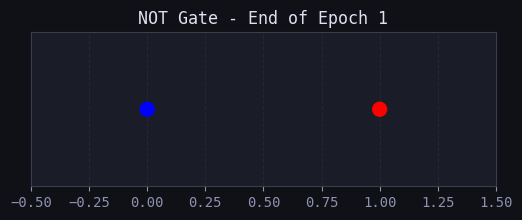

Epoch 2/10 | Errors: 1 | Weight: [-0.05] | Bias: 0.02


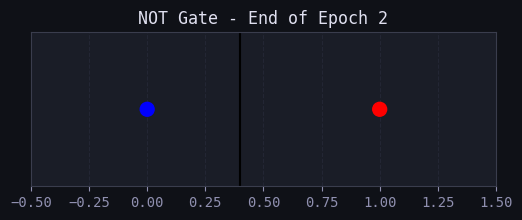

Epoch 3/10 | Errors: 0 | Weight: [-0.05] | Bias: 0.02


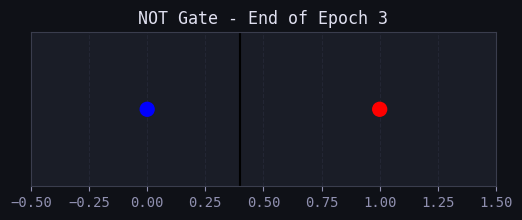


Optimal split achieved! Converged at Epoch 3.

OPTIMAL PARAMETERS FOUND
Final Weight : w = -0.050
Final Bias   : b = 0.020
Total Updates: 2


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# NOT Gate Dataset (1D Input)
# Input 0 -> Output 1
# Input 1 -> Output 0
X = np.array([
    [0],
    [1]
])

y = np.array([1, 0])

lr = 0.05  
epochs = 10

w = np.zeros(1)
b = 0.02  # Slight positive offset

def plot_boundary(X, y, w, b, title):
    plt.figure(figsize=(6, 2))  # Shorter figure since it's a 1D plot

    colors = ['red' if i == 0 else 'blue' for i in y]
    
    # Plot on a 1D number line (setting y-coordinates to 0)
    plt.scatter(X[:, 0], np.zeros_like(X[:, 0]), c=colors, s=100, zorder=3)

    # Decision boundary: w*x + b = 0 -> x = -b/w
    if abs(w[0]) > 1e-6:
        x_val = -b / w[0]
        plt.axvline(x=x_val, color='k', label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 0.5)
    plt.yticks([])  # Hide y-axis ticks since we only care about the x-axis
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.title(title)
    plt.show()

# Training Loop
total_updates = 0

for epoch in range(epochs):
    epoch_errors = 0
    
    for xi, target in zip(X, y):
        net = np.dot(xi, w) + b
        
        # Strict inequality
        pred = 1 if net > 0 else 0
        error = target - pred

        if error != 0:
            w += lr * error * xi
            b += lr * error
            total_updates += 1
            epoch_errors += 1

    print(f"Epoch {epoch + 1}/{epochs} | Errors: {epoch_errors} | Weight: {np.round(w, 3)} | Bias: {round(b, 3)}")
    plot_boundary(X, y, w, b, f"NOT Gate - End of Epoch {epoch + 1}")

    if epoch_errors == 0:
        print(f"\nOptimal split achieved! Converged at Epoch {epoch + 1}.")
        break

# Final Output
print("\n" + "="*30)
print("OPTIMAL PARAMETERS FOUND")
print("="*30)
print(f"Final Weight : w = {w[0]:.3f}")
print(f"Final Bias   : b = {b:.3f}")
print(f"Total Updates: {total_updates}")

Epoch 1/15 | Errors: 2 | Weights: [-0.05  0.  ] | Bias: -0.02


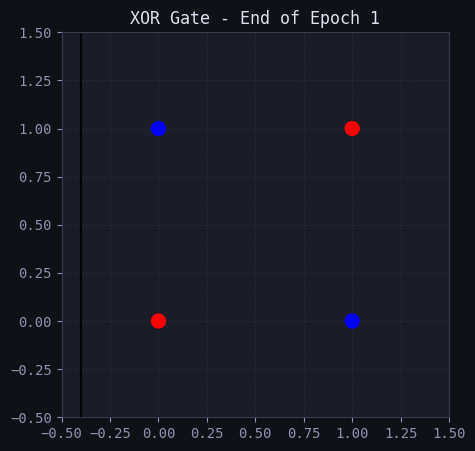

Epoch 2/15 | Errors: 3 | Weights: [-0.05  0.  ] | Bias: 0.03


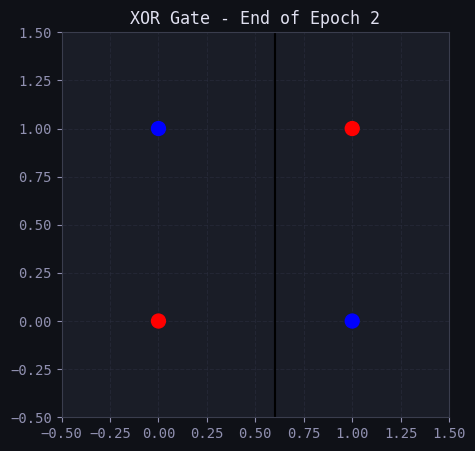

Epoch 3/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


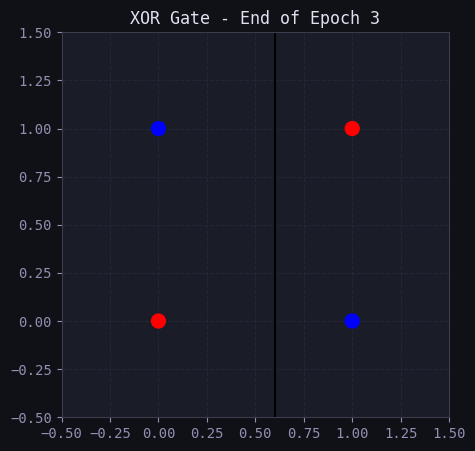

Epoch 4/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


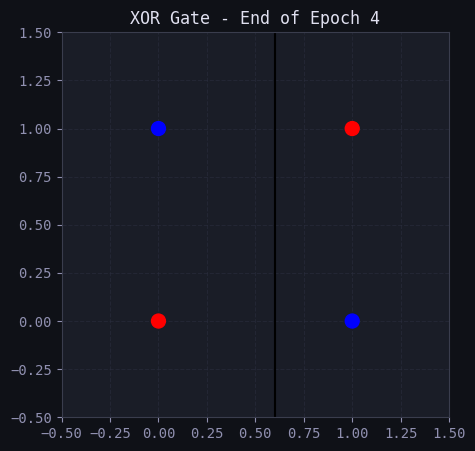

Epoch 5/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


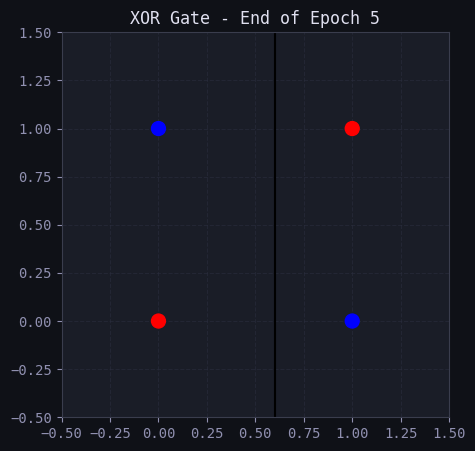

Epoch 6/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


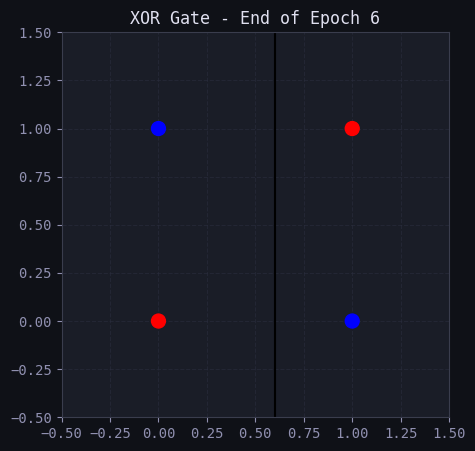

Epoch 7/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


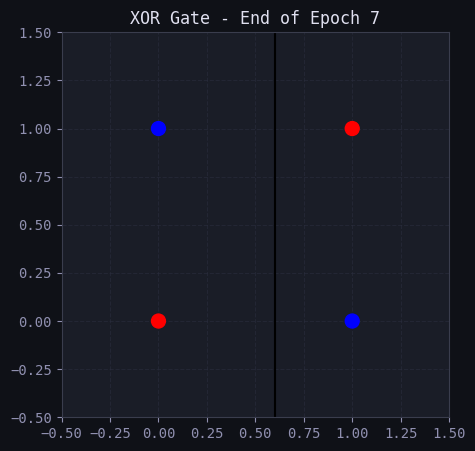

Epoch 8/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


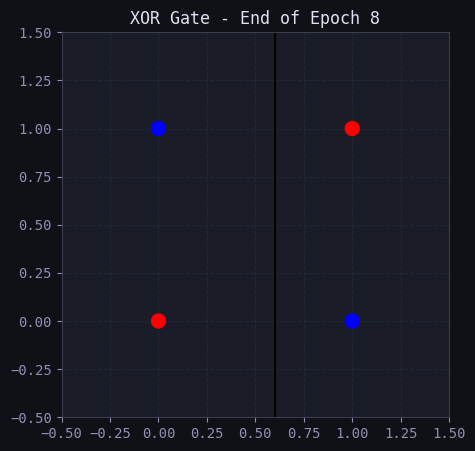

Epoch 9/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


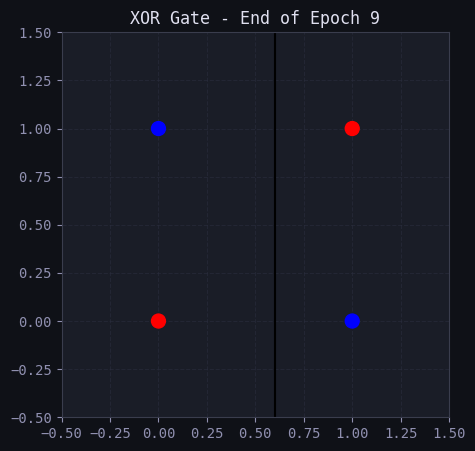

Epoch 10/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


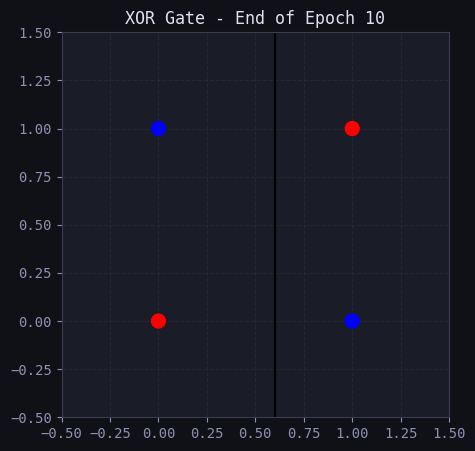

Epoch 11/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


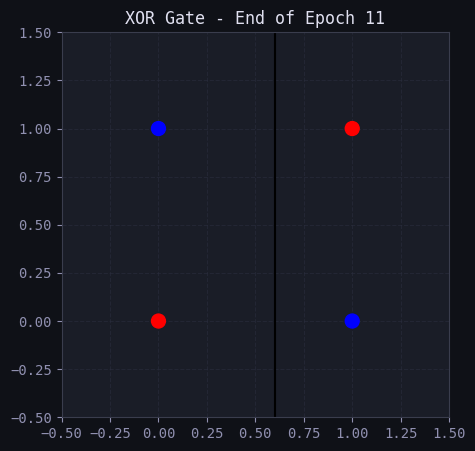

Epoch 12/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


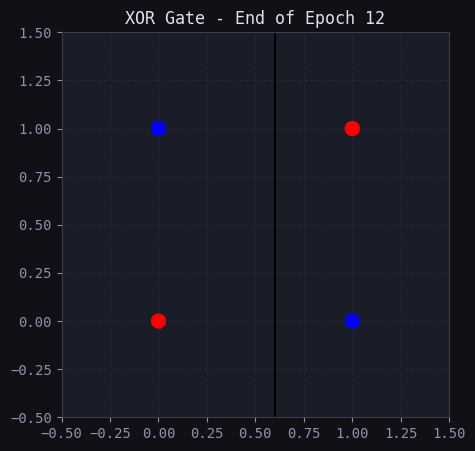

Epoch 13/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


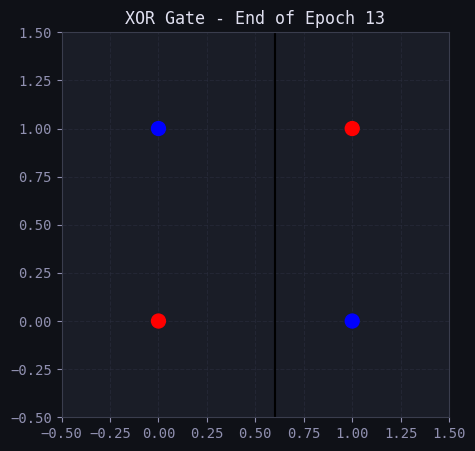

Epoch 14/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


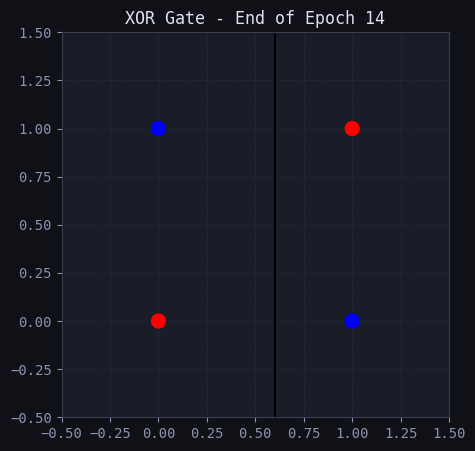

Epoch 15/15 | Errors: 4 | Weights: [-0.05  0.  ] | Bias: 0.03


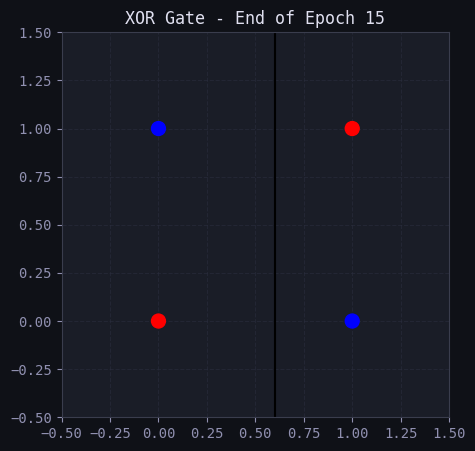


TRAINING FINISHED (MAX EPOCHS REACHED)
Final Weights : w1 = -0.050, w2 = 0.000
Final Bias    : b  = 0.030
Total Updates : 57


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# XOR Gate Dataset
# Input (0,0) -> 0 (Red)
# Input (0,1) -> 1 (Blue)
# Input (1,0) -> 1 (Blue)
# Input (1,1) -> 0 (Red)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

lr = 0.05  
epochs = 15

w = np.zeros(2)
b = -0.02  

def plot_boundary(X, y, w, b, title):
    plt.figure(figsize=(5, 5))

    colors = ['red' if i == 0 else 'blue' for i in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, s=100, zorder=3)

    if abs(w[1]) > 1e-6:
        x_pts = np.linspace(-0.5, 1.5, 100)
        y_pts = -(w[0] * x_pts + b) / w[1]
        plt.plot(x_pts, y_pts, 'k-', label='Decision Boundary')
    elif abs(w[0]) > 1e-6:
        x_val = -b / w[0]
        plt.axvline(x=x_val, color='k', label='Decision Boundary')

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.title(title)
    plt.show()

# Training Loop
total_updates = 0

for epoch in range(epochs):
    epoch_errors = 0
    
    for xi, target in zip(X, y):
        net = np.dot(xi, w) + b
        
        # Strict inequality
        pred = 1 if net > 0 else 0
        error = target - pred

        if error != 0:
            w += lr * error * xi
            b += lr * error
            total_updates += 1
            epoch_errors += 1

    print(f"Epoch {epoch + 1}/{epochs} | Errors: {epoch_errors} | Weights: {np.round(w, 3)} | Bias: {round(b, 3)}")
    plot_boundary(X, y, w, b, f"XOR Gate - End of Epoch {epoch + 1}")

    if epoch_errors == 0:
        print(f"\nOptimal split achieved! Converged at Epoch {epoch + 1}.")
        break

# Final Output
print("\n" + "="*30)
print("TRAINING FINISHED (MAX EPOCHS REACHED)")
print("="*30)
print(f"Final Weights : w1 = {w[0]:.3f}, w2 = {w[1]:.3f}")
print(f"Final Bias    : b  = {b:.3f}")
print(f"Total Updates : {total_updates}")

Analysis of XOR Gate

The perceptron learning algorithm does not converge for the XOR gate even after
10 epochs.

Reason:
• XOR is not linearly separable.
• A single straight line cannot separate the output classes.
• During training, correcting one misclassified sample often causes another
  sample to become misclassified.
• As a result, the weights continue changing from epoch to epoch instead of
  reaching stable values.

Conclusion:
The perceptron algorithm successfully converges for linearly separable problems
such as AND, OR, and NOT gates, but it fails for the XOR gate because XOR
requires a nonlinear decision boundary or a multilayer neural network.


--- Starting Perceptron Training for XOR ---

Epoch 1:
  Input: [0, 0] | Target: 0 | Pred: 1 --> UPDATED Weights: [0.00, 0.00], Bias: -0.10
  Input: [0, 1] | Target: 1 | Pred: 0 --> UPDATED Weights: [0.00, 0.10], Bias: 0.00
  Input: [1, 0] | Target: 1 | Pred: 1 --> No update
  Input: [1, 1] | Target: 0 | Pred: 1 --> UPDATED Weights: [-0.10, 0.00], Bias: -0.10

Epoch 2:
  Input: [0, 0] | Target: 0 | Pred: 0 --> No update
  Input: [0, 1] | Target: 1 | Pred: 0 --> UPDATED Weights: [-0.10, 0.10], Bias: 0.00
  Input: [1, 0] | Target: 1 | Pred: 0 --> UPDATED Weights: [0.00, 0.10], Bias: 0.10
  Input: [1, 1] | Target: 0 | Pred: 1 --> UPDATED Weights: [-0.10, 0.00], Bias: 0.00

Epoch 3:
  Input: [0, 0] | Target: 0 | Pred: 1 --> UPDATED Weights: [-0.10, 0.00], Bias: -0.10
  Input: [0, 1] | Target: 1 | Pred: 0 --> UPDATED Weights: [-0.10, 0.10], Bias: 0.00
  Input: [1, 0] | Target: 1 | Pred: 0 --> UPDATED Weights: [0.00, 0.10], Bias: 0.10
  Input: [1, 1] | Target: 0 | Pred: 1 --> UPDATED Weights

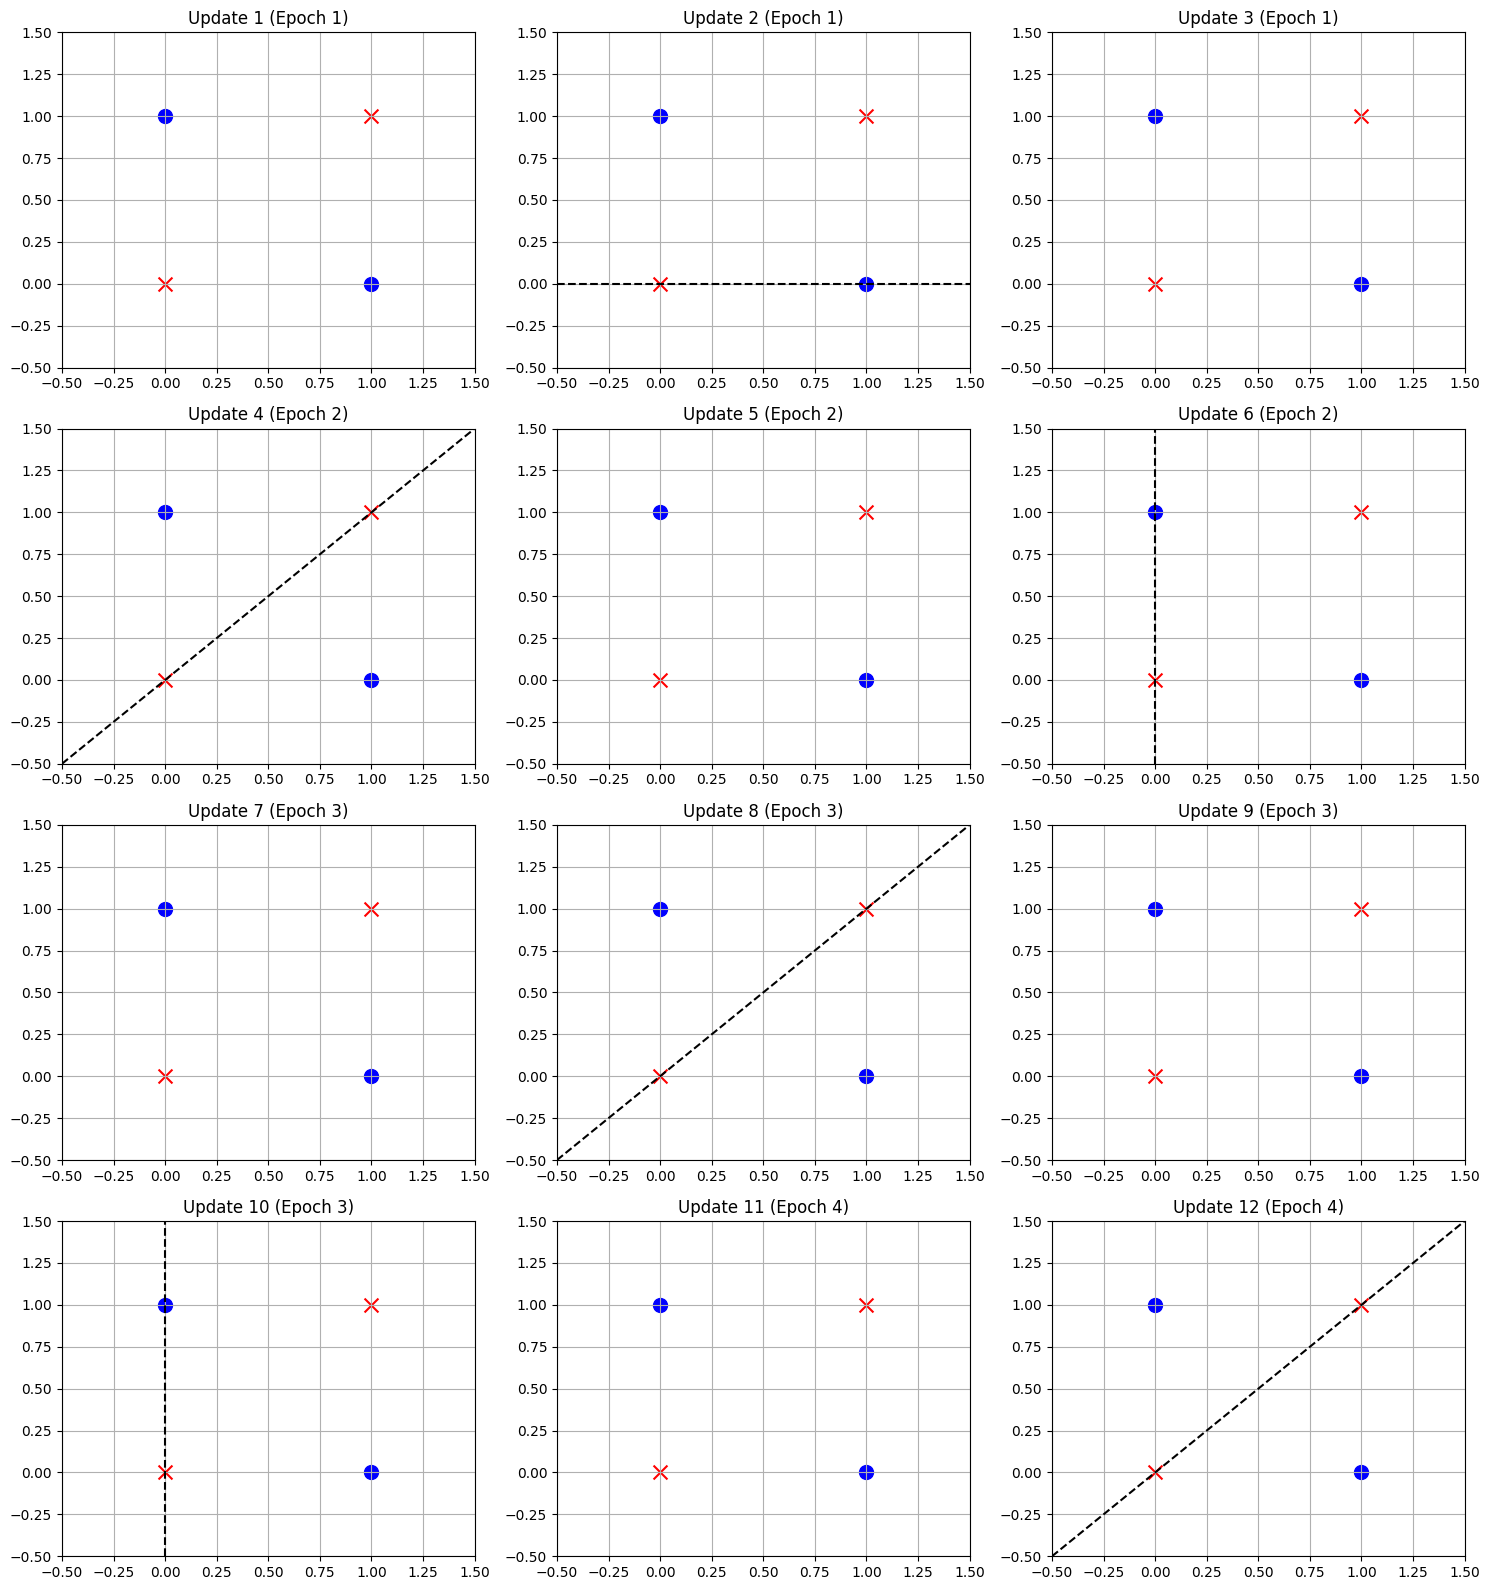


--- Training Finished ---
Notice how the weights continue to oscillate and the error never reaches zero.


In [1]:
import matplotlib.pyplot as plt

# 1. Define XOR inputs and targets
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 1, 1, 0]

# 2. Initialize weights, bias, and learning rate
W = [0.0, 0.0]
b = 0.0
lr = 0.1
epochs = 10

# Setup plotting grid (Max 12 plots to keep the Kaggle output clean)
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()
update_count = 0

print("--- Starting Perceptron Training for XOR ---")

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}:")
    for i in range(len(X)):
        x1, x2 = X[i][0], X[i][1]
        
        # Calculate linear combination
        z = (W[0] * x1) + (W[1] * x2) + b
        
        # Step activation function
        y_pred = 1 if z >= 0 else 0
        
        # Calculate error
        error = y[i] - y_pred
        
        if error != 0:
            # Update rule
            W[0] += lr * error * x1
            W[1] += lr * error * x2
            b += lr * error
            
            print(f"  Input: {X[i]} | Target: {y[i]} | Pred: {y_pred} "
                  f"--> UPDATED Weights: [{W[0]:.2f}, {W[1]:.2f}], Bias: {b:.2f}")
            
            # Plot the new decision boundary
            if update_count < len(axes):
                ax = axes[update_count]
                
                # Plot the XOR points
                for j in range(len(X)):
                    color = 'blue' if y[j] == 1 else 'red'
                    marker = 'o' if y[j] == 1 else 'x'
                    ax.scatter(X[j][0], X[j][1], color=color, marker=marker, s=100)
                
                # Calculate decision boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
                x_vals = [-0.5, 1.5]
                if W[1] != 0:
                    y_vals = [-(W[0] * x + b) / W[1] for x in x_vals]
                    ax.plot(x_vals, y_vals, 'k--')
                elif W[0] != 0: # Handle vertical boundary
                    x_val = -b / W[0]
                    ax.axvline(x=x_val, color='k', linestyle='--')
                    
                ax.set_xlim(-0.5, 1.5)
                ax.set_ylim(-0.5, 1.5)
                ax.set_title(f"Update {update_count + 1} (Epoch {epoch + 1})")
                ax.grid(True)
                
                update_count += 1
        else:
            print(f"  Input: {X[i]} | Target: {y[i]} | Pred: {y_pred} --> No update")

# Hide any unused subplots
for k in range(update_count, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

print("\n--- Training Finished ---")
print("Notice how the weights continue to oscillate and the error never reaches zero.")

--- Starting MLP Training for XOR ---


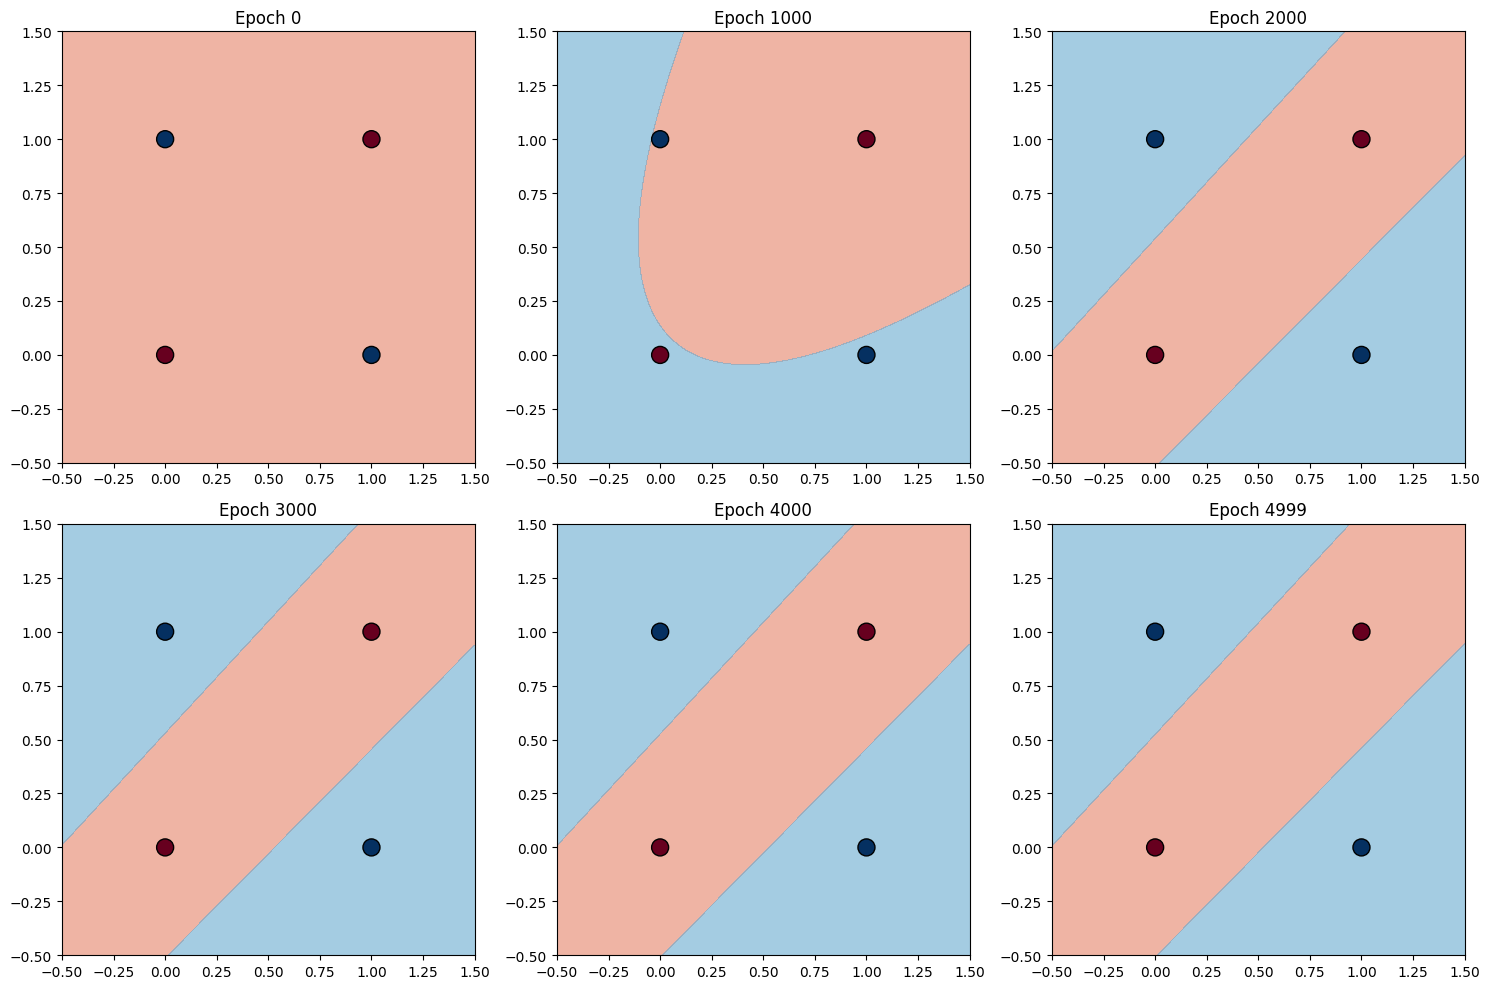


Final Predictions after 5000 Epochs:
Input: [0 0] | Target: 0 | Prediction: 0.0369
Input: [0 1] | Target: 1 | Prediction: 0.9589
Input: [1 0] | Target: 1 | Prediction: 0.9589
Input: [1 1] | Target: 0 | Prediction: 0.0331


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define XOR inputs and targets
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# 2. Define the MLP Architecture (2 Inputs -> 2 Hidden -> 1 Output)
np.random.seed(42) # For reproducible visualization
W1 = np.random.uniform(-1, 1, (2, 2)) # Weights from Input to Hidden
b1 = np.zeros((1, 2))                 # Biases for Hidden Layer
W2 = np.random.uniform(-1, 1, (2, 1)) # Weights from Hidden to Output
b2 = np.zeros((1, 1))                 # Bias for Output Layer

learning_rate = 0.5
epochs = 5000

# Non-linear activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Setup plotting grid to show boundary evolution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
plot_epochs = [0, 1000, 2000, 3000, 4000, 4999]
plot_idx = 0

print("--- Starting MLP Training for XOR ---")

for epoch in range(epochs):
    # --- Forward Propagation ---
    # Hidden Layer Transformation
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)
    
    # Output Layer Prediction
    final_input = np.dot(hidden_output, W2) + b2
    predicted_output = sigmoid(final_input)
    
    # --- Backpropagation ---
    # Calculate error at output
    error = y - predicted_output
    
    # Calculate gradients for output layer
    d_predicted_output = error * sigmoid_derivative(predicted_output)
    
    # Calculate error propagated back to hidden layer
    error_hidden = d_predicted_output.dot(W2.T)
    
    # Calculate gradients for hidden layer
    d_hidden_output = error_hidden * sigmoid_derivative(hidden_output)
    
    # Update Weights and Biases via Gradient Descent
    W2 += hidden_output.T.dot(d_predicted_output) * learning_rate
    b2 += np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate
    W1 += X.T.dot(d_hidden_output) * learning_rate
    b1 += np.sum(d_hidden_output, axis=0, keepdims=True) * learning_rate
    
    # --- Plotting the Decision Boundary ---
    if epoch in plot_epochs:
        ax = axes[plot_idx]
        
        # Create a mesh grid to map the entire decision space
        xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]
        
        # Forward pass for the grid to find the boundary
        h_grid = sigmoid(np.dot(grid, W1) + b1)
        out_grid = sigmoid(np.dot(h_grid, W2) + b2)
        Z = out_grid.reshape(xx.shape)
        
        # Plot contour and scatter points
        ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='RdBu', alpha=0.6)
        ax.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='RdBu', edgecolors='k', s=150, zorder=3)
        
        ax.set_title(f"Epoch {epoch}")
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        plot_idx += 1

plt.tight_layout()
plt.show()

print("\nFinal Predictions after 5000 Epochs:")
for i in range(len(X)):
    print(f"Input: {X[i]} | Target: {y[i][0]} | Prediction: {predicted_output[i][0]:.4f}")